# RESEARCH QUESTION 1

## Data Loading


• Visualize at least two quantitative variables and two categorical variables. Your visualizations must be relevant to your research questions!  
• Describe any trends you observe, and any relationships you may want to follow up on.  
• Explain how your visualizations should be relevant to your research questions: either by motivating the question, or suggesting a potential answer. You must explain why they are relevant.  
• All plots must have axes clearly labeled with plain English titles, and include legends where appropriate (i.e., “Electricity consumption” instead of elec_cons). All claims must be supported by the figure (e.g., if you claim an exponential trend, you should visualize on a log scale to confirm).  
• We recommend styling your plots using sns.set(...) for consistency.  
• You may include additional visualizations if useful, but we recommend limiting visualizations in your report to 8 figures or fewer.  

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import seaborn as sns
import pymc as pm
import bambi as bmb
import arviz as az
import statsmodels.api as sm
from sklearn.preprocessing import OneHotEncoder

## EPA EGRID: https://www.epa.gov/egrid

## eGRID Demographic Data

In [ ]:
egrid_demo = pd.read_csv("data/egrid2023_demo.csv")[1:]
egrid_demo_multiindex = pd.read_csv("data/egrid2023_demo.csv", header = [0,1])
egrid_demo

/tmp/ipykernel_1613/2054141767.py:1: DtypeWarning: Columns (0,1,4,5,6,9,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64) have mixed types. Specify dtype option on import or set low_memory=False.
  egrid_demo = pd.read_csv("data/egrid2023_demo.csv")[1:]


,Plant file sequence number,Data Year,Plant state abbreviation,Plant name,DOE/EIA ORIS plant or facility code,Plant latitude,Plant longitude,Plant primary fuel,Plant primary fuel category,Plant nameplate capacity (MW),...,National Percentile of Low Income,National Percentile of Less Than High School Education,National Percentile of Limited English Speaking,National Percentile of Under Age 5,National Percentile of Over Age 64,National Percentile of Unemployment Rate,National Percentile of Limited Life Expectancy,National Percentile of Demographic Index,National Percentile of Supplemental Demographic Index,Distance (miles)
1,1,2023,AK,Alakanuk,57053,62.6833,-164.6544,DFO,OIL,0.8,...,94,83,64,96,13,96,NaN,97,82,3
2,2,2023,AK,Allison Creek Hydro,58982,61.084444,-146.353333,WAT,HYDRO,6.5,...,23,31,0,0,61,60,11,35,27,3
3,3,2023,AK,Ambler,60243,67.08798,-157.856719,DFO,OIL,1.1,...,88,80,66,89,34,95,81,93,76,3
4,4,2023,AK,Angoon,7462,57.499166,-134.58614,DFO,OIL,1.5,...,82,58,67,66,85,97,43,84,70,3
5,5,2023,AK,Aniak,7182,61.580678,-159.535643,DFO,OIL,1.7,...,80,75,0,80,22,92,87,87,72,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12608,12614,2023,WY,TransAlta Wyoming Wind,56093,41.2874,-110.5556,WND,WIND,144.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0
12609,12615,2023,WY,Wygen I,55479,44.2858,-105.3833,SUB,COAL,90.0,...,54.0,49.0,0.0,31.0,60.0,31.0,48.0,39.0,43.0,3.0
12610,12616,2023,WY,Wygen II,56319,44.2919,-105.3811,SUB,COAL,95.0,...,54.0,47.0,0.0,34.0,58.0,34.0,43.0,38.0,41.0,3.0
12611,12617,2023,WY,Wygen III,56596,44.2919,-105.3806,SUB,COAL,116.0,...,54.0,47.0,0.0,34.0,58.0,34.0,42.0,38.0,41.0,3.0


In [ ]:
egrid_plant = pd.read_csv("data/egrid2023_plant.csv")[1:]
egrid_plant

/tmp/ipykernel_1613/1590308207.py:1: DtypeWarning: Columns (0,1,4,6,8,16,17,19,20,22,23,27,29,33,34,35,50,51,52,53,55,56,58,59,60,61,62,63,64,65,66,67,68,69,71,72,74,82,85,86,97,98,99,102,107,122) have mixed types. Specify dtype option on import or set low_memory=False.
  egrid_plant = pd.read_csv("data/egrid2023_plant.csv")[1:]


,Plant file sequence number,Data Year,Plant state abbreviation,Plant name,DOE/EIA ORIS plant or facility code,Plant transmission or distribution system owner name,Plant transmission or distribution system owner ID,Utility name,Utility ID,Plant-level sector,...,Plant geothermal generation percent (resource mix),Plant other fossil generation percent (resource mix),Plant other unknown / purchased fuel generation percent (resource mix),Plant total nonrenewables generation percent (resource mix),Plant total renewables generation percent (resource mix),Plant total nonrenewables other unknown/purchased generation percent (resource mix),Plant total nonhydro renewables generation percent (resource mix),Plant total combustion generation percent (resource mix),Plant total noncombustion generation percent (resource mix),Plant total noncombustion other unknown/purchased generation percent (resource mix)
1,1,2023,AK,Alakanuk,57053,"Alaska Village Elec Coop, Inc",221,"Alaska Village Elec Coop, Inc",221,Electric Utility,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2023,AK,Allison Creek Hydro,58982,"Copper Valley Elec Assn, Inc",4329,"Copper Valley Elec Assn, Inc",4329,Electric Utility,...,0.0%,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%,0.0%,100.0%,0.0%
3,3,2023,AK,Ambler,60243,"Alaska Village Elec Coop, Inc",221,"Alaska Village Elec Coop, Inc",221,Electric Utility,...,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%
4,4,2023,AK,Angoon,7462,"Inside Passage Elec Coop, Inc",18963,"Inside Passage Elec Coop, Inc",18963,Electric Utility,...,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%
5,5,2023,AK,Aniak,7182,Aniak Light & Power Co Inc,4959,Aniak Light & Power Co Inc,4959,Electric Utility,...,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12608,12608,2023,WY,TransAlta Wyoming Wind,56093,PacifiCorp,14354,NextEra Energy Operating Services LLC,58528,IPP Non-CHP,...,0.0%,0.0%,0.0%,0.0%,100.0%,0.0%,100.0%,0.0%,100.0%,0.0%
12609,12609,2023,WY,Wygen I,55479,Black Hills Power Inc,19545,"Black Hills Power, Inc.",19545,IPP Non-CHP,...,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%
12610,12610,2023,WY,Wygen II,56319,Black Hills Power Inc,19545,"Black Hills Power, Inc.",19545,Electric Utility,...,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%
12611,12611,2023,WY,Wygen III,56596,Black Hills Power Inc,19545,"Black Hills Power, Inc.",19545,Electric Utility,...,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%


In [ ]:
egrid_joined = pd.merge(egrid_plant, egrid_demo, on="DOE/EIA ORIS plant or facility code")
egrid_joined.head()

,Plant file sequence number_x,Data Year_x,Plant state abbreviation_x,Plant name_x,DOE/EIA ORIS plant or facility code,Plant transmission or distribution system owner name,Plant transmission or distribution system owner ID,Utility name,Utility ID,Plant-level sector,...,National Percentile of Low Income,National Percentile of Less Than High School Education,National Percentile of Limited English Speaking,National Percentile of Under Age 5,National Percentile of Over Age 64,National Percentile of Unemployment Rate,National Percentile of Limited Life Expectancy,National Percentile of Demographic Index,National Percentile of Supplemental Demographic Index,Distance (miles)
0,1,2023,AK,Alakanuk,57053,"Alaska Village Elec Coop, Inc",221,"Alaska Village Elec Coop, Inc",221,Electric Utility,...,94,83,64,96,13,96,NaN,97,82,3
1,2,2023,AK,Allison Creek Hydro,58982,"Copper Valley Elec Assn, Inc",4329,"Copper Valley Elec Assn, Inc",4329,Electric Utility,...,23,31,0,0,61,60,11,35,27,3
2,3,2023,AK,Ambler,60243,"Alaska Village Elec Coop, Inc",221,"Alaska Village Elec Coop, Inc",221,Electric Utility,...,88,80,66,89,34,95,81,93,76,3
3,4,2023,AK,Angoon,7462,"Inside Passage Elec Coop, Inc",18963,"Inside Passage Elec Coop, Inc",18963,Electric Utility,...,82,58,67,66,85,97,43,84,70,3
4,5,2023,AK,Aniak,7182,Aniak Light & Power Co Inc,4959,Aniak Light & Power Co Inc,4959,Electric Utility,...,80,75,0,80,22,92,87,87,72,3


In [ ]:
#Extract county FIPS from egrid data

#relevant_columns = ['Plant primary fuel category_x', 'Plant annual net generation (MWh)', 'Total Population', 'People of Color (%)', 'Low Income (%)', 'Less Than High School Education (%)', 'Limited English Speaking (%)', 'Unemployment Rate (%)', 'Limited Life Expectancy (%)', 'Demographic Index', "National Percentile of Over Age 64"]

#rename after merge
egrid_joined['Plant state abbreviation'] = egrid_joined['Plant state abbreviation_x']
egrid_joined['Plant latitude'] = egrid_joined['Plant latitude_x']
egrid_joined['Plant longitude'] = egrid_joined['Plant longitude_x']

# dropna for any relevant column
num_blocks_dropped = egrid_joined[['Plant FIPS state code', 'Plant FIPS county code','Plant state abbreviation','Plant county name', 'Plant latitude', 'Plant longitude', 'Total Population', 'People of Color (%)', 'Low Income (%)', 'Less Than High School Education (%)', 'Limited English Speaking (%)', 'Unemployment Rate (%)', 'Limited Life Expectancy (%)', 'Under Age 5 (%)', 'Over Age 64 (%)']].isnull().any(axis=1).sum()
egrid_dropped = egrid_joined.dropna(subset=['Plant FIPS state code', 'Plant FIPS county code','Plant state abbreviation','Plant county name', 'Plant latitude', 'Plant longitude', 'Total Population', 'People of Color (%)', 'Low Income (%)', 'Less Than High School Education (%)', 'Limited English Speaking (%)', 'Unemployment Rate (%)', 'Limited Life Expectancy (%)', 'Under Age 5 (%)', 'Over Age 64 (%)'])
#egrid_dropped['Plant FIPS state code str'] = egrid_dropped['Plant FIPS state code'].astype(int).astype(str)

#force the FIPS state code to numeric, make it an integer (some were floating point) fill it to the default 2 spaces (e.g 8 become 08)
egrid_dropped['Plant FIPS state code'] = pd.to_numeric(egrid_dropped['Plant FIPS state code'], errors='coerce')
egrid_dropped['Plant FIPS state code'] = egrid_dropped['Plant FIPS state code'].astype(int).astype(str).str.zfill(2)

#force the FIPS county code to numeric, fill it to the default 3 spaces (e.g 1 become 001)
egrid_dropped['Plant FIPS county code'] = pd.to_numeric(egrid_dropped['Plant FIPS county code'], errors='coerce')
egrid_dropped['Plant FIPS county code'] = egrid_dropped['Plant FIPS county code'].astype(int).astype(str).str.zfill(3)  #county, state codes sometimes int or decimal

# concatenate State and County FIPS for unique ID
egrid_dropped['County FIPS'] = egrid_dropped['Plant FIPS state code'] + egrid_dropped['Plant FIPS county code']

# assign plant counties to treatment group
egrid_dropped['has_plant'] = 1

# relevant columns for multiple hypothesis testing
columns_select = ['County FIPS', 'Plant county name', 'Plant state abbreviation','Plant latitude', 'Plant longitude', 'has_plant', 'Total Population', 'People of Color (%)', 'Low Income (%)', 'Less Than High School Education (%)', 'Limited English Speaking (%)', 'Unemployment Rate (%)', 'Limited Life Expectancy (%)', "Plant primary fuel category_x", "Plant annual net generation (MWh)", 'Over Age 64 (%)', 'Under Age 5 (%)']
egridf = egrid_dropped[columns_select]

# clean columns used for analysis that have odd formatting and discrepancies
clean_me = ['Total Population', 'People of Color (%)', 'Low Income (%)', 'Less Than High School Education (%)', 'Limited English Speaking (%)', 'Unemployment Rate (%)', 'Limited Life Expectancy (%)', 'Over Age 64 (%)', 'Under Age 5 (%)']
for col in clean_me:
    cleaned = egrid_dropped[col].astype(str).str.replace(r'[,\(\)]', '', regex=True)
    egridf[col] = pd.to_numeric(cleaned, errors='coerce')
    num_blocks_dropped += egridf.isnull().any(axis=1).sum()
    egridf = egridf.dropna()
    egridf[col] = egridf[col].astype(int)

num_blocks_dropped += egridf.isnull().any(axis=1).sum()
egridf.dropna()
print(f'Number of plant communities dropped in processing: {num_blocks_dropped} with 7756 remaining (about 9% loss)')
egridf.shape



Number of plant communities dropped in processing: 760 with 7756 remaining (about 9% loss)


/tmp/ipykernel_1613/923742257.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  egrid_dropped['Plant FIPS state code'] = pd.to_numeric(egrid_dropped['Plant FIPS state code'], errors='coerce')
/tmp/ipykernel_1613/923742257.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  egrid_dropped['Plant FIPS state code'] = egrid_dropped['Plant FIPS state code'].astype(int).astype(str).str.zfill(2)
/tmp/ipykernel_1613/923742257.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a

(7756, 17)

In [ ]:
# add regions to egridf for regional exploration based on EPA regional categorization
epa_regions_by_state = {
    'CT': 1, 'ME': 1, 'MA': 1, 'NH': 1, 'RI': 1, 'VT': 1,
    'NJ': 2, 'NY': 2, 'PR': 2, 'VI': 2,
    'DE': 3, 'DC': 3, 'MD': 3, 'PA': 3, 'VA': 3, 'WV': 3,
    'AL': 4, 'FL': 4, 'GA': 4, 'KY': 4, 'MS': 4, 'NC': 4, 'SC': 4, 'TN': 4,
    'IL': 5, 'IN': 5, 'MI': 5, 'MN': 5, 'OH': 5, 'WI': 5,
    'AR': 6, 'LA': 6, 'NM': 6, 'OK': 6, 'TX': 6,
    'IA': 7, 'KS': 7, 'MO': 7, 'NE': 7,
    'CO': 8, 'MT': 8, 'ND': 8, 'SD': 8, 'UT': 8, 'WY': 8,
    'AZ': 9, 'CA': 9, 'HI': 9, 'NV': 9, 'AS': 9, 'GU': 9, 'MP': 9, 'FM': 9, 'MH': 9, 'PW': 9,
    'AK': 10, 'ID': 10, 'OR': 10, 'WA': 10
}


egridf['EPA Region'] = egridf['Plant state abbreviation'].map(epa_regions_by_state)

In [ ]:
plant_per_county = egridf.groupby("County FIPS").size()
plant_per_county_plusone = plant_per_county[plant_per_county > 1]
print(f'There are {plant_per_county_plusone.size} counties with more than one utility plant')

There are 1005 counties with more than one utility plant


In [ ]:
egridf.to_csv('data/egrid_counties.csv')

It's important to note that there are only 1422 unique counties, but over 7,000 plants. Thats because the plant is pulling the information of a 3 mile radius around it, and there may be multiple plants in one county. One reason that could be for this is one county having multiple different types of plants. Lets see below:

## Data Processing for Non-Host Communities
Data obtained here: https://zenodo.org/records/14767363  
egrid details here: https://www.epa.gov/system/files/documents/2025-01/egrid2023_technical_guide.pdf  
ejscreen in action here: https://pedp-ejscreen.azurewebsites.net/  
ejscreen documentation here: https://www.epa.gov/system/files/documents/2024-07/ejscreen-tech-doc-version-2-3.pdf  
other resource i couldnt figure out: https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/RLR5AX  
ejscreen tool archive: https://screening-tools.com/epa-ejscreen  


In [ ]:
import requests
# ref https://www.geeksforgeeks.org/python/how-to-download-files-from-urls-with-python/#

#This is census data for each block group id, it gives the mean latitude and longitude
url = 'https://www2.census.gov/geo/docs/reference/cenpop2020/blkgrp/CenPop2020_Mean_BG.txt'

response = requests.get(url)
file_path = 'data/CenPop2020_Mean_BG.txt'

if response.status_code == 200:
    with open(file_path, 'wb') as file:
        file.write(response.content)
    print('File downloaded successfully')
else:
    print('Failed to download file')

File downloaded successfully


In [ ]:
#block group means
mean_bg = pd.read_csv(file_path)

mean_bg['STATEFP'] = mean_bg['STATEFP'].astype(str).str.zfill(2)
mean_bg['COUNTYFP'] = mean_bg['COUNTYFP'].astype(str).str.zfill(3)
mean_bg['TRACTCE'] = mean_bg['TRACTCE'].astype(str).str.zfill(6)
mean_bg['BLKGRPCE'] = mean_bg['BLKGRPCE'].astype(str).str.zfill(1)
mean_bg['ID'] = mean_bg['STATEFP']+ mean_bg['COUNTYFP'] + mean_bg['TRACTCE'] + mean_bg['BLKGRPCE']
#rad needed for efficient nearest plant finding
mean_bg['LAT_RAD'] = np.deg2rad(mean_bg['LATITUDE'])
mean_bg['LON_RAD'] = np.deg2rad(mean_bg['LONGITUDE'])

mean_bg = mean_bg[['ID', 'LAT_RAD', 'LON_RAD']].set_index('ID')
mean_bg

,LAT_RAD,LON_RAD
ID,,
010010201001,0.566612,-1.509471
010010201002,0.566931,-1.509478
010010202001,0.566854,-1.509264
010010202002,0.566640,-1.509202
010010203001,0.566846,-1.509009
...,...,...
721537506011,0.314508,-1.166594
721537506012,0.314512,-1.166662
721537506013,0.314437,-1.166711


In [ ]:
use_cols = [
    'ID',
    'REGION',
    'PEOPCOLOR',
    'ACSTOTPOP', #Total population
    'LOWINCOME', 'ACSIPOVBAS', #Population for whom poverty status is determined
    'UNEMPLOYED',  'ACSUNEMPBAS', #Unemployment base--persons in civilian labor force (unemployment rate)
    'LINGISO', #Limited English speaking households
    'ACSTOTHH', #Households (for limited English speaking)
    'LESSHS',
    'ACSEDUCBAS', #Population 25 years and over (use for less than hs)
    'UNDER5',
    'OVER64',
    'P_LIFEEXPPCT',
    'ST_ABBREV',
    'CNTY_NAME'
]

cols_agg = {
    'ST_ABBREV': 'first',
    'REGION': 'first',
    'CNTY_NAME':'first',
    'PEOPCOLOR': 'sum',
    'ACSTOTPOP': 'sum',
    'LOWINCOME': 'sum',
    'ACSIPOVBAS': 'sum',
    'UNEMPLOYED': 'sum',
    'ACSUNEMPBAS': 'sum',
    'LINGISO':'sum',
    'ACSTOTHH': 'sum',
    'LESSHS': 'sum',
    'ACSEDUCBAS': 'sum',
    'UNDER5': 'sum',
    'OVER64': 'sum',

}

In [ ]:
from sklearn.neighbors import BallTree

egrid = pd.read_csv('data/egrid_counties.csv', index_col = 0)
#put plant locations points into radian tuples for balltree
egrid['LAT_RAD'] = np.deg2rad(egrid['Plant latitude'])
egrid['LON_RAD'] = np.deg2rad(egrid['Plant longitude'])
plant_locs = np.array(egrid[['LAT_RAD', 'LON_RAD']])

output = pd.DataFrame()
df = pd.read_csv('data/EJSCREEN_2023_BG_with_AS_CNMI_GU_VI.csv',  usecols = use_cols, encoding = 'latin1', chunksize = 10000)

#BallTree ref: https://autogis-site.readthedocs.io/en/2021/notebooks/L3/06_nearest-neighbor-faster.html#:~:text=While%20Shapely's%20nearest_points%20%2Dfunction%20provides,terms%20of%20supported%20distance%20metrics.
#scikit-learn’s haversine distance metric wants inputs as radians and also outputs the data as radians.
tree = BallTree(plant_locs, metric='haversine')
num_blocks_dropped = 0
for chunk in df:

    chunk['ID'] = chunk['ID'].astype(str).str.zfill(12)
    #get latitude and longitude in radians for each census block in chunk
    chunk = chunk.merge(mean_bg, how='left', left_on='ID', right_index=True)
    num_blocks_dropped += chunk[['LAT_RAD', 'LON_RAD']].isnull().any(axis=1).sum()
    chunk = chunk.dropna(subset=['LAT_RAD', 'LON_RAD'])

    block_locs = chunk[['LAT_RAD', 'LON_RAD']]

    #find nearest plant for each block group center, distance = dist from block to closest plant (nearest neighbor)
    distance, indice = tree.query(block_locs, k=1)

    # Convert to miles from radians where 3959 is earths mean radius in miles
    chunk['DIST_TO_PLANT'] = distance * 3958.8

    # non host communities defined to be > 3 miles and < 50 miles away from a plant
    chunk = chunk[chunk['DIST_TO_PLANT'] > 3]
    chunk = chunk[chunk['DIST_TO_PLANT'] < 50 ]

    if not chunk.empty:
        chunk['County FIPS'] = chunk['ID'].astype(str).str.zfill(12).str[:5] #fill front with 0s in case fips codes should be 12 digits
        chunk_grouped = chunk.groupby('County FIPS').agg(cols_agg) #group within chunk for efficiency, but will need to repeat at end
        output = pd.concat([chunk_grouped, output])

    #display(output)
    #break
#output
final_df = output.groupby(output.index).agg(cols_agg).reset_index()
display(final_df)
print(f'Out of over 240k block groups, only {num_blocks_dropped} were not dropped from missing latitude and longitude')

FileNotFoundError: [Errno 2] No such file or directory: 'data/EJSCREEN_2023_BG_with_AS_CNMI_GU_VI.csv'

In [ ]:
#renaming and calculating to match eGRID naming

# note that need to divide by different column values as specified in EJScreen technical guide
final_df['Total Population'] = final_df['ACSTOTPOP']
final_df['People of Color (%)'] = (final_df['PEOPCOLOR'] / final_df['ACSTOTPOP']) * 100
final_df['Low Income (%)'] = (final_df['LOWINCOME'] / final_df['ACSIPOVBAS']) * 100 #divide by Population for whom poverty status is determined
final_df['Unemployment Rate (%)'] = (final_df['UNEMPLOYED'] / final_df['ACSUNEMPBAS']) * 100 #Unemployment base--persons in civilian labor force (unemployment rate)
final_df['Limited English Speaking (%)'] = (final_df['LINGISO'] / final_df['ACSTOTHH']) * 100 #Households (for limited English speaking)
final_df['Less Than High School Education (%)'] = (final_df['LESSHS'] / final_df['ACSEDUCBAS']) * 100 #Population 25 years and over (use for less than hs)
final_df['Under Age 5 (%)'] = (final_df['UNDER5'] / final_df['ACSTOTPOP']) * 100
final_df['Over Age 64 (%)'] = (final_df['OVER64'] / final_df['ACSTOTPOP']) * 100
final_df['Plant state abbreviation'] = final_df['ST_ABBREV']
final_df['Plant county name'] = final_df['CNTY_NAME']
final_df['has_plant'] = 0
final_df['EPA Region'] = final_df['REGION']


In [ ]:
df_drop = final_df.dropna() #only 6 rows dropped
save_df = df_drop[['County FIPS', 'Plant state abbreviation', 'Plant county name', 'EPA Region','has_plant','Total Population', 'People of Color (%)', 'Low Income (%)', 'Less Than High School Education (%)', 'Limited English Speaking (%)', 'Unemployment Rate (%)', 'Under Age 5 (%)', 'Over Age 64 (%)']]
save_df.to_csv('data/EJScreen_DEMO23.csv')
save_df

## Combining with US Census of all counties

In [ ]:
ejscreen = pd.read_csv('data/EJScreen_DEMO23.csv', index_col=0)
ejscreen['County FIPS'] = ejscreen['County FIPS'].astype(str).str.zfill(5) #full digit profile lost when reading from csv
ejscreen

,County FIPS,Plant state abbreviation,Plant county name,EPA Region,has_plant,Total Population,People of Color (%),Low Income (%),Less Than High School Education (%),Limited English Speaking (%),Unemployment Rate (%),Under Age 5 (%),Over Age 64 (%)
0,01001,AL,Autauga County,4,0,58239,26.902934,30.770029,10.415510,0.146413,2.824625,5.697213,15.135905
1,01003,AL,Baldwin County,4,0,227131,17.427388,25.847738,8.985844,0.837252,3.685828,5.298704,20.607051
2,01005,AL,Barbour County,4,0,25259,55.390158,50.314607,24.328980,1.287412,8.624186,5.225860,19.007087
3,01007,AL,Bibb County,4,0,22412,25.950384,40.404762,19.461917,0.324721,9.706819,5.336427,16.036052
4,01009,AL,Blount County,4,0,58884,14.076829,33.465357,16.351923,1.582160,6.023723,5.887847,17.974322
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2574,56037,WY,Sweetwater County,8,0,42459,21.705645,22.398131,7.294363,1.976946,6.713718,6.257802,12.694599
2575,56039,WY,Teton County,8,0,23319,20.073760,21.523236,3.969647,4.889309,2.402089,4.579956,15.476650
2576,56041,WY,Uinta County,8,0,20514,12.971629,25.687078,6.430892,1.641694,3.467517,6.887979,14.731403
2577,56043,WY,Washakie County,8,0,6845,20.525931,23.853073,6.220807,0.340832,2.671862,5.084003,21.183346


In [ ]:
ejscreen_tojoin = ejscreen[['County FIPS', 'Plant state abbreviation', 'Plant county name', 'EPA Region', 'has_plant', 'Total Population', 'People of Color (%)', 'Low Income (%)', 'Less Than High School Education (%)', 'Limited English Speaking (%)', 'Unemployment Rate (%)', 'Over Age 64 (%)', 'Under Age 5 (%)']]
joined = pd.concat([ejscreen_tojoin, egridf])
assert joined[joined['County FIPS'].str.len() != 5].shape[0] == 0 #all fips code for countys should be len 5

In [ ]:
joined = joined.drop_duplicates()
joined

,County FIPS,Plant state abbreviation,Plant county name,EPA Region,has_plant,Total Population,People of Color (%),Low Income (%),Less Than High School Education (%),Limited English Speaking (%),Unemployment Rate (%),Over Age 64 (%),Under Age 5 (%),Plant latitude,Plant longitude,Limited Life Expectancy (%),Plant primary fuel category_x,Plant annual net generation (MWh)
0,01001,AL,Autauga County,4,0,58239,26.902934,30.770029,10.415510,0.146413,2.824625,15.135905,5.697213,NaN,NaN,NaN,NaN,NaN
1,01003,AL,Baldwin County,4,0,227131,17.427388,25.847738,8.985844,0.837252,3.685828,20.607051,5.298704,NaN,NaN,NaN,NaN,NaN
2,01005,AL,Barbour County,4,0,25259,55.390158,50.314607,24.328980,1.287412,8.624186,19.007087,5.225860,NaN,NaN,NaN,NaN,NaN
3,01007,AL,Bibb County,4,0,22412,25.950384,40.404762,19.461917,0.324721,9.706819,16.036052,5.336427,NaN,NaN,NaN,NaN,NaN
4,01009,AL,Blount County,4,0,58884,14.076829,33.465357,16.351923,1.582160,6.023723,17.974322,5.887847,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8510,56009,WY,Converse,8,1,289,11.000000,24.000000,6.000000,0.000000,0.000000,16.000000,5.000000,42.9258,-105.7872,18.0,WIND,"254,753"
8512,56005,WY,Campbell,8,1,1861,16.000000,29.000000,8.000000,0.000000,2.000000,19.000000,3.000000,44.2858,-105.3833,19.0,COAL,"643,236"
8513,56005,WY,Campbell,8,1,1638,15.000000,29.000000,7.000000,0.000000,2.000000,18.000000,3.000000,44.2919,-105.3811,19.0,COAL,"663,372"
8514,56005,WY,Campbell,8,1,1649,15.000000,29.000000,7.000000,0.000000,2.000000,18.000000,3.000000,44.2919,-105.3806,19.0,COAL,"794,708"


In [ ]:
joined.to_csv('data/mh_analysis_ready.csv') # save for multiple hypothesis notebook

## EDA

### Plant primary fuel category

In [ ]:
fuel_type = egridf.groupby("Plant primary fuel category_x").mean(numeric_only = True)
fuel_type

,has_plant,Total Population,People of Color (%),Low Income (%),Less Than High School Education (%),Limited English Speaking (%),Unemployment Rate (%),Limited Life Expectancy (%),Over Age 64 (%),Under Age 5 (%),EPA Region
Plant primary fuel category_x,,,,,,,,,,,
BIOMASS,1.0,26821.545238,37.240476,30.350000,12.400000,3.533333,5.764286,18.511905,17.807143,5.559524,5.783333
COAL,1.0,6774.844444,21.059259,31.533333,10.266667,1.222222,4.777778,19.429630,19.925926,4.933333,5.651852
GAS,1.0,76107.321601,46.220842,31.768806,13.397516,5.180124,5.783299,18.258109,15.453416,5.838509,5.873706
GEOTHERMAL,1.0,5608.272727,46.250000,42.750000,15.750000,6.136364,4.909091,15.386364,17.545455,6.181818,8.954545
HYDRO,1.0,9337.471645,21.836484,30.477316,9.776938,1.640832,5.495274,17.740076,21.673913,4.787335,6.315690
NUCLEAR,1.0,4147.114286,20.285714,24.285714,11.428571,1.200000,5.571429,19.114286,22.228571,4.171429,4.142857
OFSL,1.0,49189.500000,48.250000,34.083333,15.666667,4.750000,7.083333,18.833333,16.166667,5.916667,6.500000
OIL,1.0,73119.385686,37.986083,31.433400,10.926441,3.333996,6.111332,18.240557,17.383698,5.825050,5.532803
OTHF,1.0,45275.540541,47.898649,32.216216,15.148649,6.682432,6.574324,18.175676,17.006757,6.141892,6.878378


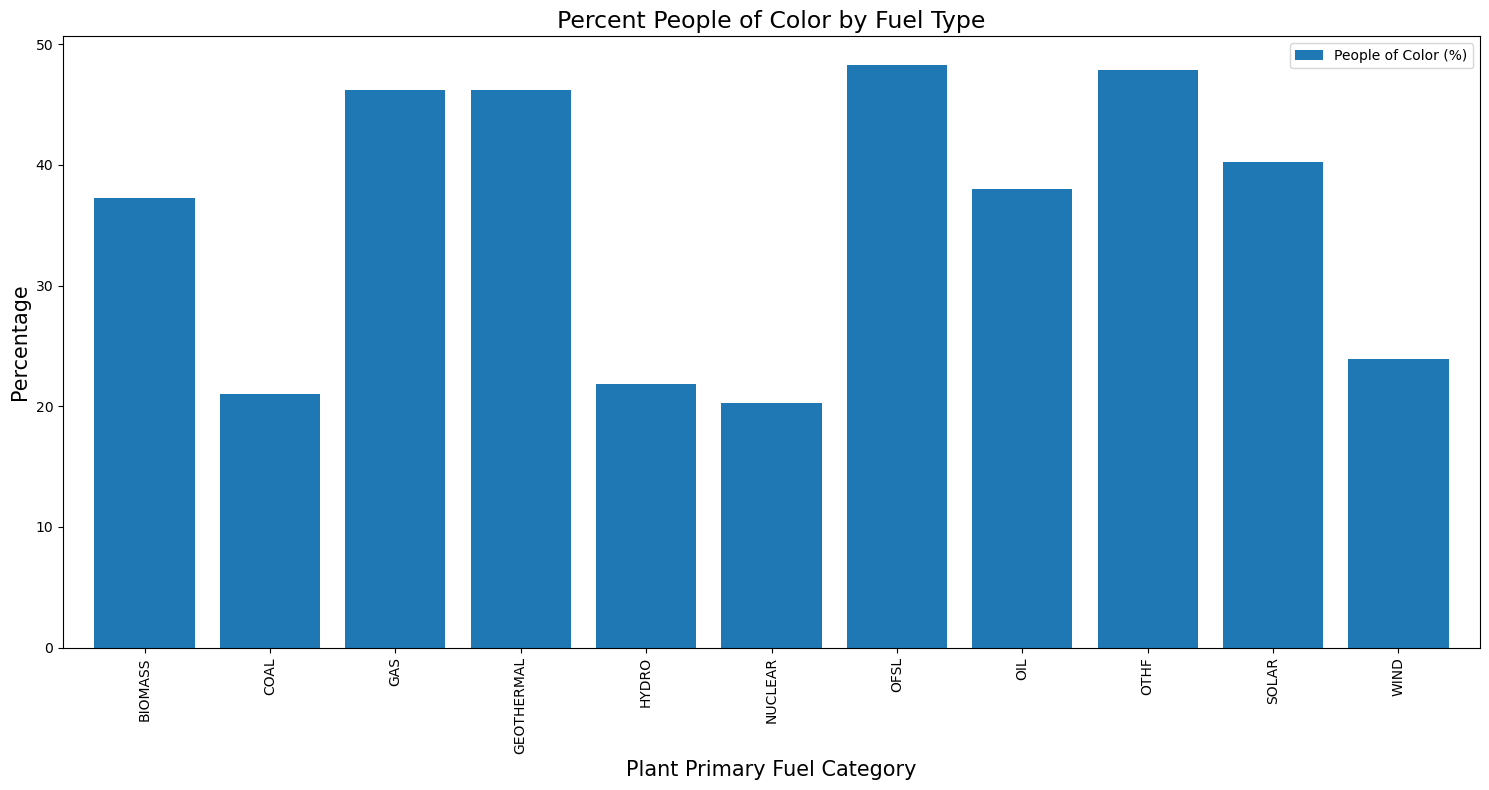

In [ ]:
ax = fuel_type[['People of Color (%)']].plot(kind='bar', figsize=(15, 8), width=0.8)
plt.title("Percent People of Color by Fuel Type", fontsize=17)
plt.xlabel("Plant Primary Fuel Category", fontsize=15)
plt.ylabel("Percentage", fontsize=15)
plt.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [ ]:
egridf.describe().T

,count,mean,std,min,25%,50%,75%,max
has_plant,7756.0,1.000000,0.000000,1.0,1.0,1.0,1.00,1.0
Total Population,7756.0,32887.796931,98120.696194,0.0,741.0,4882.5,26679.25,1337436.0
People of Color (%),7756.0,36.491619,26.996412,0.0,13.0,30.0,56.00,100.0
Low Income (%),7756.0,31.491748,13.884680,0.0,21.0,30.0,40.00,93.0
Less Than High School Education (%),7756.0,12.671996,9.282496,0.0,6.0,10.0,16.00,82.0
Limited English Speaking (%),7756.0,3.885379,6.605344,0.0,0.0,1.0,5.00,66.0
Unemployment Rate (%),7756.0,5.723311,4.283479,0.0,3.0,5.0,7.00,45.0
Limited Life Expectancy (%),7756.0,18.166452,4.059774,0.0,16.0,18.0,21.00,30.0
Over Age 64 (%),7756.0,17.937855,7.251173,0.0,13.0,17.0,21.00,86.0
Under Age 5 (%),7756.0,5.489299,2.493993,0.0,4.0,5.0,7.00,26.0


In [ ]:
joined.describe().T

In [ ]:
joined

,County FIPS,Plant state abbreviation,Plant county name,EPA Region,has_plant,Total Population,People of Color (%),Low Income (%),Less Than High School Education (%),Limited English Speaking (%),Unemployment Rate (%),Over Age 64 (%),Under Age 5 (%),Plant latitude,Plant longitude,Limited Life Expectancy (%),Plant primary fuel category_x,Plant annual net generation (MWh)
0,01001,AL,Autauga County,4,0,58239,26.902934,30.770029,10.415510,0.146413,2.824625,15.135905,5.697213,NaN,NaN,NaN,NaN,NaN
1,01003,AL,Baldwin County,4,0,227131,17.427388,25.847738,8.985844,0.837252,3.685828,20.607051,5.298704,NaN,NaN,NaN,NaN,NaN
2,01005,AL,Barbour County,4,0,25259,55.390158,50.314607,24.328980,1.287412,8.624186,19.007087,5.225860,NaN,NaN,NaN,NaN,NaN
3,01007,AL,Bibb County,4,0,22412,25.950384,40.404762,19.461917,0.324721,9.706819,16.036052,5.336427,NaN,NaN,NaN,NaN,NaN
4,01009,AL,Blount County,4,0,58884,14.076829,33.465357,16.351923,1.582160,6.023723,17.974322,5.887847,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8510,56009,WY,Converse,8,1,289,11.000000,24.000000,6.000000,0.000000,0.000000,16.000000,5.000000,42.9258,-105.7872,18.0,WIND,"254,753"
8512,56005,WY,Campbell,8,1,1861,16.000000,29.000000,8.000000,0.000000,2.000000,19.000000,3.000000,44.2858,-105.3833,19.0,COAL,"643,236"
8513,56005,WY,Campbell,8,1,1638,15.000000,29.000000,7.000000,0.000000,2.000000,18.000000,3.000000,44.2919,-105.3811,19.0,COAL,"663,372"
8514,56005,WY,Campbell,8,1,1649,15.000000,29.000000,7.000000,0.000000,2.000000,18.000000,3.000000,44.2919,-105.3806,19.0,COAL,"794,708"


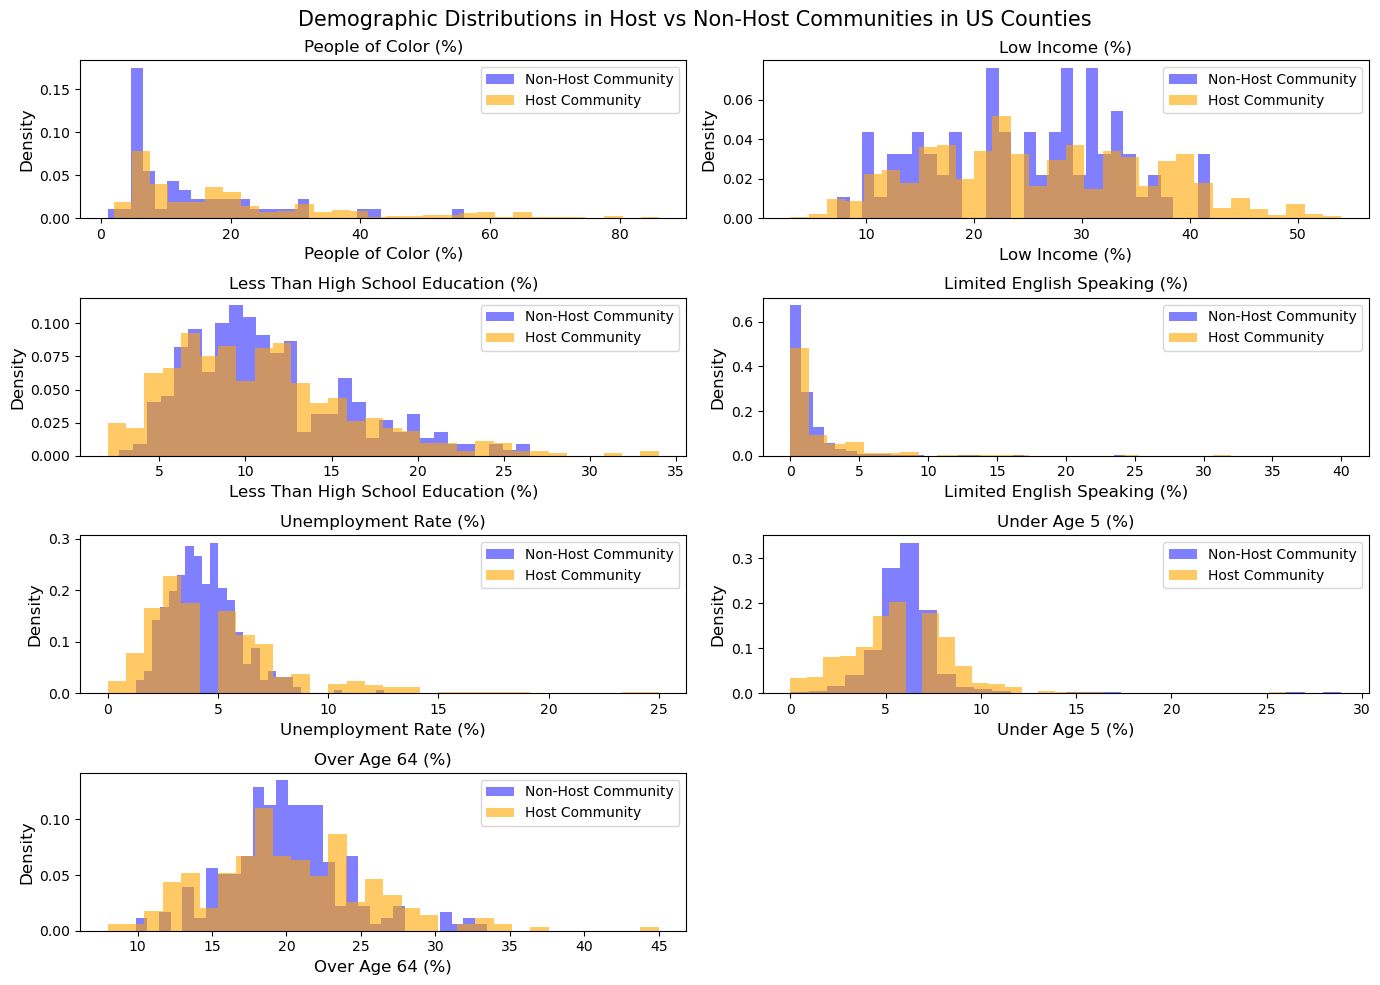

In [ ]:
# Create a figure with 2 rows and 3 columns
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 10))
axes = axes.flatten()
cols = ['People of Color (%)', 'Low Income (%)', 'Less Than High School Education (%)', 'Limited English Speaking (%)','Unemployment Rate (%)', 'Under Age 5 (%)', 'Over Age 64 (%)']

for i, col in enumerate(cols):
    ax = axes[i]

    # histogram of demo % for non host communities
    ax.hist(
        joined[(joined['has_plant'] == 0) & (joined['EPA Region']== i+1)][col],
        bins=30,
        alpha=0.5,
        label='Non-Host Community',
        color='blue',
        density=True
    )

    # histogram of demo % for host communities
    ax.hist(
        joined[(joined['has_plant'] == 1) & (joined['EPA Region']== i+1)][col],
        bins=30,
        alpha=0.6,
        label='Host Community',
        color='orange',
        density=True
    )

    ax.set_title(f'{col}')
    ax.set_xlabel(f'{col}')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Demographic Distributions in Host vs Non-Host Communities in US Counties', fontsize = 15)
plt.tight_layout()

fig.delaxes(fig.axes[-1])
plt.show()

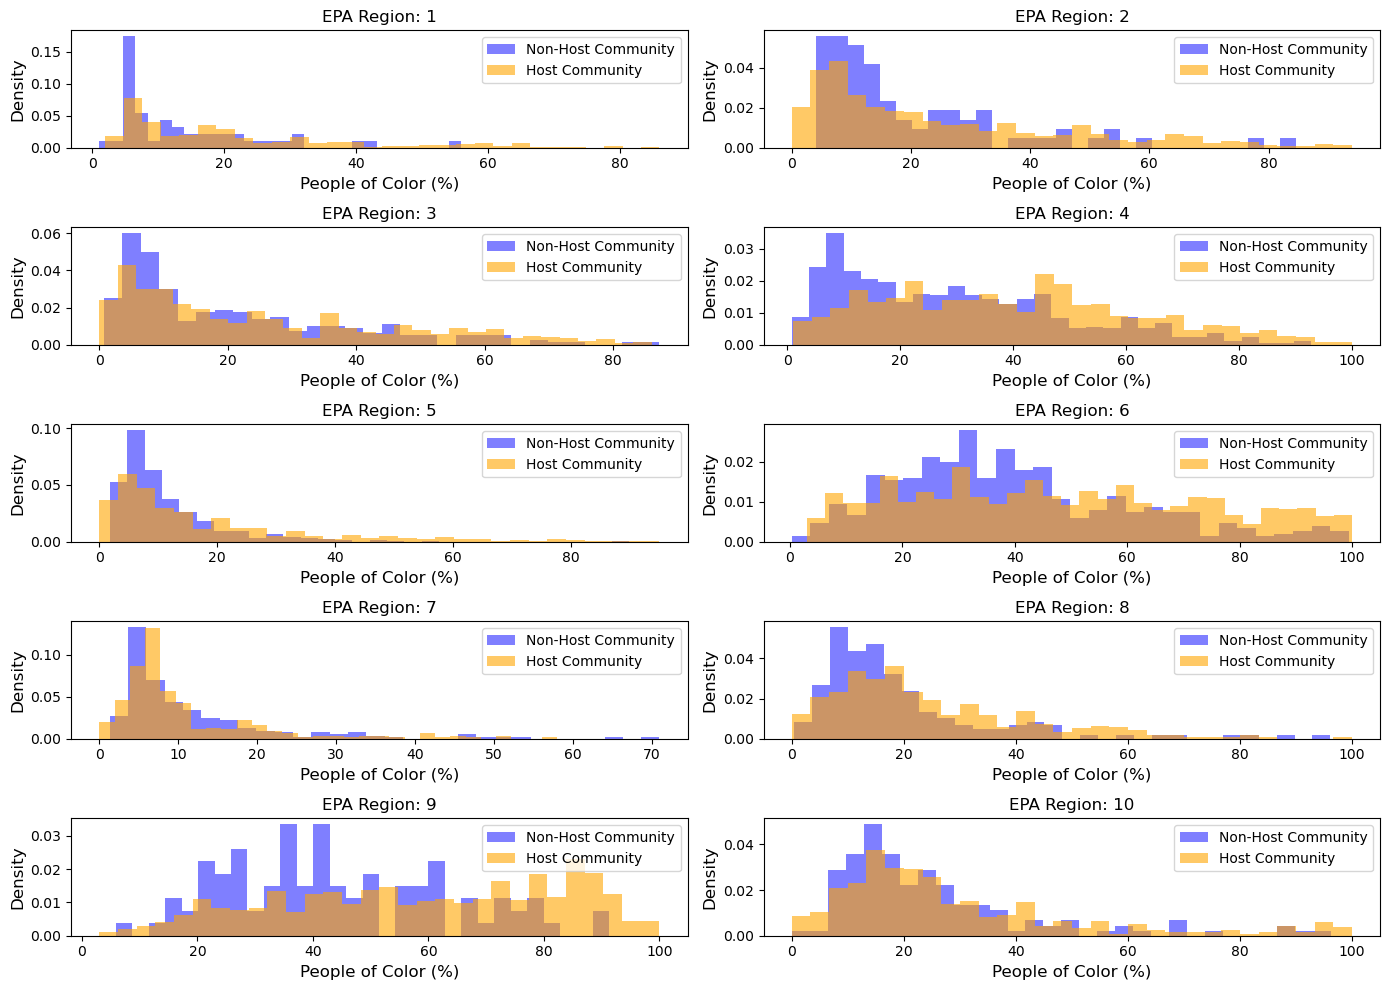

In [ ]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14, 10))
axes = axes.flatten()

#10 total regions
for i in np.arange(10):
    ax = axes[i]

    # histogram of people of color % for non host communities
    ax.hist(
        joined[(joined['has_plant'] == 0) & (joined['EPA Region']== i+1)]['People of Color (%)'],
        bins=30,
        alpha=0.5,
        label='Non-Host Community',
        color='blue',
        density=True
    )

    # histogram of people of color % for host communities
    ax.hist(
        joined[(joined['has_plant'] == 1) & (joined['EPA Region']== i+1)]['People of Color (%)'],
        bins=30,
        alpha=0.6,
        label='Host Community',
        color='orange',
        density=True
    )

    ax.set_title(f'EPA Region: {i+1}')
    ax.set_xlabel('People of Color (%)')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

## Hypothesis

Our general hypothesis is that the location of plants are disproportionately placed in marginalized communities. The characteristic of a marginalized community is not singular, which illicts the need to conduct multiple hypothesis testing to observe potential inequalities across multiple socioeconomic demographic metrics.

Our alternative hypotheses are as follows:
1) Plants are disproportionately located in areas with higher % People of Color
2) Plants are disproportionately located in areas with higher % Low Income
3) Plants are disproportionately located in areas with higher % Less Than High School Education
4) Plants are disproportionately located in areas with higher % Limited English speaking households
5) Plants are disproportionately located in areas with higher % Unemployment Rate
6) There is a difference in the percentage of people under age 5 for counties with plants vs. without
7) There is a difference in the percentage of people over age 64 for counties with plants vs. without


Our null hypotheses are that there is no difference in means of these demographic factors between counties with plants and counties without plants.

We will be conducting A/B testing against each hypothesis. This is because we can treat each plant in the eGRID data as the 'treatment' of having a plant. The other counties across the US will be the control groups, for not having a plant.

To correct for the multiple hypothesis tests, we will use two different methods:
- To control the FDR at 0.05, we will use the Benjamini–Yekutieli procedure, which controls the false discovery rate under arbitrary dependence assumptions. This is needed because the demographic metrics are not independent due to the socioeconomic functioning of the US.(could add EDA on this w a correlation map)
- To control for the FWER at 0.05, we will use the Bonferroni correction.


In [ ]:
counties = pd.read_csv('data/mh_analysis_ready.csv', index_col=0)
counties

,County FIPS,Plant state abbreviation,Plant county name,EPA Region,has_plant,Total Population,People of Color (%),Low Income (%),Less Than High School Education (%),Limited English Speaking (%),Unemployment Rate (%),Over Age 64 (%),Under Age 5 (%),Plant latitude,Plant longitude,Limited Life Expectancy (%),Plant primary fuel category_x,Plant annual net generation (MWh)
0,1001,AL,Autauga County,4,0,58239,26.902934,30.770029,10.415510,0.146413,2.824625,15.135905,5.697213,NaN,NaN,NaN,NaN,NaN
1,1003,AL,Baldwin County,4,0,227131,17.427388,25.847738,8.985844,0.837252,3.685828,20.607051,5.298704,NaN,NaN,NaN,NaN,NaN
2,1005,AL,Barbour County,4,0,25259,55.390158,50.314607,24.328980,1.287412,8.624186,19.007087,5.225860,NaN,NaN,NaN,NaN,NaN
3,1007,AL,Bibb County,4,0,22412,25.950384,40.404762,19.461917,0.324721,9.706819,16.036052,5.336427,NaN,NaN,NaN,NaN,NaN
4,1009,AL,Blount County,4,0,58884,14.076829,33.465357,16.351923,1.582160,6.023723,17.974322,5.887847,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8510,56009,WY,Converse,8,1,289,11.000000,24.000000,6.000000,0.000000,0.000000,16.000000,5.000000,42.925800,-105.787200,18.0,WIND,"254,753"
8512,56005,WY,Campbell,8,1,1861,16.000000,29.000000,8.000000,0.000000,2.000000,19.000000,3.000000,44.285800,-105.383300,19.0,COAL,"643,236"
8513,56005,WY,Campbell,8,1,1638,15.000000,29.000000,7.000000,0.000000,2.000000,18.000000,3.000000,44.291900,-105.381100,19.0,COAL,"663,372"
8514,56005,WY,Campbell,8,1,1649,15.000000,29.000000,7.000000,0.000000,2.000000,18.000000,3.000000,44.291900,-105.380600,19.0,COAL,"794,708"


In [ ]:
# **Credit note: the functions below were based off of Reily Fairchild's homework 1 code that she developed, augmented to fit our analysis here.
def difference_of_means(df, group_label, numerical_col, abs_dif):
    """
    Calculate difference in means, dependent on one or two sided test
        df: dataframe
        numerical_col (string): a numerical column name
        binary_col (string): a binary column name that will be shuffled
        i (integer): simmulation random state
        abs_dif (bool): whether it is a one sided or two sided alternative hypothesis
    """
    series = df.groupby('Shuffled Label').mean().loc[:, numerical_col]
    if abs_dif == True:
        return abs(series.iloc[1] - series.iloc[0])
    else:
        return series.iloc[1] - series.iloc[0]

In [ ]:
def one_simulated_difference_of_means(df, numerical_col, binary_col, i, abs_dif):
    """
   The function computes a single simulation of an A/B permutation and the difference of means.
    inputs
        df: dataframe
        numerical_col (string): a numerical column name
        binary_col (string): a binary column name that will be shuffled
        i (integer): simmulation random state
        abs_dif (bool): whether it is a one sided or two sided alternative hypothesis
    """
    shuffled_df = df.copy()

    shuffled_labels = df.sample(replace=False, frac = 1, random_state = i)[binary_col]
    shuf = shuffled_labels.to_numpy()
    shuffled_df['Shuffled Label'] = shuf
    selected_shuf = shuffled_df.loc[:, (numerical_col, 'Shuffled Label')]

    return difference_of_means(selected_shuf, 'Shuffled Label', numerical_col, abs_dif)

In [ ]:
def avg_difference_in_means(df, numerical_col, abs_dif, binary_col= 'has_plant'):
    """
   The function computes the p-value for a test of the following hypothesis test:
        H0 : There is no difference in the average value of numerical_col between the two
            groups specified in binary_col.
        H1 : The average value of numerical_col is different for the two groups specified
            in binary_col
    inputs
        numerical_col: a numerical column name
        binary_col: a binary column name
    """
    selected = df.loc[:, (numerical_col, binary_col)]
    series_obs = selected.groupby(binary_col).mean().loc[:, numerical_col]
    if abs_dif == True:
        observed_difference = abs(series_obs.iloc[1] - series_obs.iloc[0])
    else:
        observed_difference = series_obs.iloc[1] - series_obs.iloc[0]
    differences = []

    repetitions = 2500
    for i in np.arange(repetitions):
        new_difference = one_simulated_difference_of_means(df, numerical_col, binary_col, i, abs_dif)
        differences = np.append(differences, new_difference)

    empirical_p = np.count_nonzero(differences >= observed_difference) / repetitions #how many samples have as extreme of a difference?

    #print(f' observed dif: {observed_difference}, empirical p: {empirical_p}')
    return empirical_p


In [ ]:
one_sided_cols = ['People of Color (%)', 'Low Income (%)', 'Less Than High School Education (%)', 'Unemployment Rate (%)', 'Limited English Speaking (%)']
two_sided_cols = ['Over Age 64 (%)', 'Under Age 5 (%)']
#binary_col = 'has_plant'
pvals = {}

# one sided alternative hypothesis, namely higher %
for i in one_sided_cols:
    pvals[f'{i}'] = avg_difference_in_means(counties, i, abs_dif = True)
# two sided alternative hypothesis for ages
for k in two_sided_cols:
    pvals[f'{k}'] = avg_difference_in_means(counties, k, abs_dif = False)

pvals

{'People of Color (%)': 0.0,
 'Low Income (%)': 0.0,
 'Less Than High School Education (%)': 0.0064,
 'Unemployment Rate (%)': 0.0,
 'Limited English Speaking (%)': 0.0,
 'Over Age 64 (%)': 1.0,
 'Under Age 5 (%)': 0.994}

### Bonferroni Procedure and FWER Discoveries

In [ ]:
fwer = 0.05
num_tests = len(one_sided_cols) + len(two_sided_cols)
fwer_threshold = fwer / num_tests
print(f'FWER threshold: {fwer_threshold}')
reject_null = [x for x in list(pvals.keys()) if pvals[x] <= fwer_threshold]

print(f'There are {len(reject_null)} discoveries made when controlling FWER are {reject_null}')


FWER threshold: 0.0071428571428571435
There are 5 discoveries made when controlling FWER are ['People of Color (%)', 'Low Income (%)', 'Less Than High School Education (%)', 'Unemployment Rate (%)', 'Limited English Speaking (%)']


### Benjamini–Yekutieli Procedure and FDR Discoveries

In [ ]:
p_sorted = sorted(list(pvals.values()))

m = len(p_sorted)
k = np.arange(1, m+1)  # index of each test in sorted order
alpha = 0.05 # desired FPR
c_m = np.sum([1/i for i in range(1, m)]) # Benjamini–Yekutieli procedure's 'harmonic function'
compare = (alpha * k) /(m * c_m) # B-y threshold
below_than = p_sorted <= compare
cols = {'k' : k, 'p-vals' : p_sorted, 'compare': compare, 'below than' : below_than}

ps = pd.DataFrame(cols)
ps


,k,p-vals,compare,below than
0,1,0.0000,0.002915,True
1,2,0.0000,0.005831,True
2,3,0.0000,0.008746,True
3,4,0.0000,0.011662,True
4,5,0.0064,0.014577,True
5,6,0.9940,0.017493,False
6,7,1.0000,0.020408,False


In [ ]:
fdr_threshold = ps[ps['below than'] == True]['p-vals'].iloc[-1]
print(f'FDR threshold: {fdr_threshold}')
fdr_reject_null = [x for x in list(pvals.keys()) if pvals[x] <= fdr_threshold]
#list(pvals.values())

print(f'The are {len(fdr_reject_null)} discoveries made when controlling FDR are {fdr_reject_null}')

FDR threshold: 0.0064
The are 5 discoveries made when controlling FDR are ['People of Color (%)', 'Low Income (%)', 'Less Than High School Education (%)', 'Unemployment Rate (%)', 'Limited English Speaking (%)']


### Specific Alternative Test and Likelihood Ratio Test

Null: In the United State, the distribution of % People of Color is the same for counties with energy plants as for counties without. The difference in the sample is due to chance.  
Simple Alternative: In the United States, the counties with energy plants have 3% more People of Color, on average, than the counties without energy plants.

The 3% was decided based on a similar study which found that communities with oil plants were 2.6% more Black, 4.2% more Latinx, and 1.4% more Asian than communities without oil plants. https://www.sciencedirect.com/science/article/pii/S221462962300110X#s0055


In [ ]:
from scipy.stats import norm
def simple_alt_hyp(df, numerical_col, binary_col= 'has_plant'):
    """
   The function computes the power for a simple alternative hypothesis test:
        H0 : There is no difference in the average value of numerical_col between the two
            groups specified in binary_col.
        H1 : The average value of numerical_col is 3%
    inputs
        df: dataframe
        numerical_col: a numerical column name
        binary_col: the treatment column name
    """
    selected = df.loc[:, (numerical_col, binary_col)]
    series_obs = selected.groupby(binary_col).mean().loc[:, numerical_col]
    observed_difference = series_obs.iloc[1] - series_obs.iloc[0]

    #calculate std of the difference between means (source: https://www.bmj.com/about-bmj/resources-readers/publications/statistics-square-one/5-differences-between-means-type-i-an)
    sd_err_of_mean_treatment = (df[df[binary_col] == 1][numerical_col].std() **2) / len(df[df[binary_col] == 1][numerical_col]) #treatments std/n
    sd_err_of_mean_control = (df[df[binary_col] == 0][numerical_col].std() **2) / len(df[df[binary_col] == 0][numerical_col]) #control std/n
    std = np.sqrt((sd_err_of_mean_treatment) + (sd_err_of_mean_control))

    # desired FPR
    fpr = 0.05

    # threshold = 95% quantile under the null ie any observed dif that is in the area to the right of this point will be rejected
    threshold = norm.ppf(1-fpr, loc=0, scale=std)

    #power = TPR : p( rejecting the null, given alt hypothesis is true) so p(LR > n) | x is alt
    # p( x > threshold) under the alternative
    power = 1 - norm.cdf(threshold, loc=3, scale=std)

    print(f'The observed difference is {observed_difference}, the threshold is {threshold}, and the power is: {power}')
    if observed_difference > threshold:
        print('Because the observed difference is greater than the threshold, we reject the null')
    else:
        print('Because the observed difference is not greater than the threshold, we fail to reject the null')
    return power


In [ ]:
simple_alt_hyp(counties, 'People of Color (%)');

The observed difference is 11.89399468701766, the threshold is 0.8235939462410474, and the power is: 0.9999930881732889
Because the observed difference is greater than the threshold, we reject the null


# RESEARCH QUESTION 2

## Data Loading

### Imports

In [1]:
import numpy as np
import requests
import pandas as pd
from bs4 import BeautifulSoup
import io

### Treatment : Price
We scrape our treatment data from Energy Information Administration website

In [4]:
# extract list of state codes from EIA website
url = "https://www.eia.gov/dnav/pet/pet_pri_dfp1_k_m.htm"
page = requests.get(url)
soup = BeautifulSoup(page.text, "html.parser")

exclude_codes = ["F009960", "F001236", "F003075", "F005071", "F005061", "F005074"]

codes = []
for link in soup.find_all("a"):
    href = link.get("href", "")
    text = link.text.strip()
    if "s=F" in href and "&f=M" in href:
        code = href.split("s=")[-1].split("&")[0]
        num_part = int(code[1:7])
        if num_part % 1000 == 0:
          continue
        if code[:7] in exclude_codes:
          continue
        codes.append(code)
display(codes)

['F001242__3',
 'F001354__3',
 'F002017__3',
 'F002018__3',
 'F002020__3',
 'F002021__3',
 'F002026__3',
 'F002031__3',
 'F002038__3',
 'F002039__3',
 'F002040__3',
 'F002046__3',
 'F003001__3',
 'F003005__3',
 'F003022__3',
 'F003028__3',
 'F003035__3',
 'F003048__3',
 'F004008__3',
 'F004030__3',
 'F004049__3',
 'F004056__3',
 'F005006__3']

In [5]:
all_data = []
API_URL = "https://api.eia.gov/v2/petroleum/pri/dfp1/data/"

# call the EIA API
for code in codes:
    params = {
        "api_key": "vUc8dcxSykilX0CpePaERE6F0NRipDBTqiB1Jl51",
        "frequency": "monthly",
        "data[0]": "value",
        "facets[series][]": code,
        "sort[0][column]": "period",
        "sort[0][direction]": "desc",
        "offset": 0,
        "length": 5000
    }
    try:
      response = requests.get(API_URL, params=params)
      response.raise_for_status()
      data = response.json()

      # Extract records
      for r in data['response']['data']:
          all_data.append({
              "State_Code": code,
              "Period": r['period'],
              "Price": r['value']
          })
    except Exception as e:
      print(f"Error fetching data for code {code}: {e}")

# Convert to DataFrame and process as before
df = pd.DataFrame(all_data)
df['Period'] = pd.to_datetime(df['Period'])
df['Year'] = df['Period'].dt.year
df['Month'] = df['Period'].dt.month
df = df[(df['Year'] >= 1978) & (df['Year'] <= 2024)]
df.sort_values(by=['State_Code', 'Year', 'Month'], inplace=True)

df.head()

,State_Code,Period,Price,Year,Month
572,F001242__3,1978-01-01,14.71,1978,1
571,F001242__3,1978-02-01,14.8,1978,2
570,F001242__3,1978-03-01,14.74,1978,3
569,F001242__3,1978-04-01,14.67,1978,4
568,F001242__3,1978-05-01,14.71,1978,5


In [7]:
# data cleaning: remove rows where price is withdrawn
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df = df.dropna(subset=['Price'])
df = df.reset_index(drop=True)

In [8]:
# add state column
state_mapping = {
    'F001242__3': 'PA',
    'F001354__3': 'WV',
    'F002017__3': 'IL',
    'F002018__3': 'IN',
    'F002020__3': 'KS',
    'F002021__3': 'KY',
    'F002026__3': 'MI',
    'F002031__3': 'NE',
    'F002038__3': 'ND',
    'F002039__3': 'OH',
    'F002040__3': 'OK',
    'F002046__3': 'SD',
    'F003001__3': 'AL',
    'F003005__3': 'AR',
    'F003022__3': 'LA',
    'F003028__3': 'MS',
    'F003035__3': 'NM',
    'F003048__3': 'TX',
    'F004008__3': 'CO',
    'F004030__3': 'MT',
    'F004049__3': 'UT',
    'F004056__3': 'WY',
    'F005006__3': 'CA'
}

# get state mappings
df['state'] = df['State_Code'].map(state_mapping)
print(df.head(10))
print(df.shape)

   State_Code     Period  Price  Year  Month state
0  F001242__3 1978-01-01  14.71  1978      1    PA
1  F001242__3 1978-02-01  14.80  1978      2    PA
2  F001242__3 1978-03-01  14.74  1978      3    PA
3  F001242__3 1978-04-01  14.67  1978      4    PA
4  F001242__3 1978-05-01  14.71  1978      5    PA
5  F001242__3 1978-06-01  14.72  1978      6    PA
6  F001242__3 1978-07-01  14.75  1978      7    PA
7  F001242__3 1978-08-01  14.65  1978      8    PA
8  F001242__3 1978-09-01  14.70  1978      9    PA
9  F001242__3 1978-10-01  14.78  1978     10    PA
(12784, 6)


### Outcome : Consumption
We join our outcome variable data from external data source: https://www.eia.gov/electricity/data/state/

In [ ]:
cons_csv = pd.read_csv('data/consumption_data.csv')
cons_csv.head(20)

In [ ]:
# filter for only petroleum derived electricity consumption
cons_csv = cons_csv[(cons_csv['ENERGY SOURCE              (UNITS)'].str.contains('Petroleum')) & (cons_csv['TYPE OF PRODUCER']=='Total Electric Power Industry')]
print(cons_csv.head())
print(cons_csv.shape)

    YEAR MONTH STATE               TYPE OF PRODUCER  \
1   2001     1    AK  Total Electric Power Industry   
13  2001     1    AL  Total Electric Power Industry   
29  2001     1    AR  Total Electric Power Industry   
39  2001     1    AZ  Total Electric Power Industry   
51  2001     1    CA  Total Electric Power Industry   

   ENERGY SOURCE              (UNITS) CONSUMPTION  
1                 Petroleum (Barrels)     124,998  
13                Petroleum (Barrels)     284,241  
29                Petroleum (Barrels)     209,194  
39                Petroleum (Barrels)     268,016  
51                Petroleum (Barrels)     960,824  
(15392, 6)


In [ ]:
# join the two tables
cons_csv['YEAR'] = cons_csv['YEAR'].astype('int32')
cons_csv['MONTH'] = cons_csv['MONTH'].astype('int32')
df = df.merge(cons_csv, left_on=['Year', 'state', 'Month'], right_on=['YEAR', 'STATE', 'MONTH'], how='inner')
df = df.drop(columns=['YEAR', 'STATE', 'MONTH'])

# data cleaning : set to numeric
df['CONSUMPTION'] = pd.to_numeric(
    df['CONSUMPTION'].astype(str).str.replace(',', ''),
    errors='coerce'
).astype(pd.Int64Dtype())
print(df.head())
print(df.shape)

   State_Code     Period  Price  Year  Month state  \
0  F001242__3 2001-01-01  28.02  2001      1    PA   
1  F001242__3 2001-02-01  28.52  2001      2    PA   
2  F001242__3 2001-03-01  26.20  2001      3    PA   
3  F001242__3 2001-04-01  26.31  2001      4    PA   
4  F001242__3 2001-05-01  27.43  2001      5    PA   

                TYPE OF PRODUCER ENERGY SOURCE              (UNITS)  \
0  Total Electric Power Industry                Petroleum (Barrels)   
1  Total Electric Power Industry                Petroleum (Barrels)   
2  Total Electric Power Industry                Petroleum (Barrels)   
3  Total Electric Power Industry                Petroleum (Barrels)   
4  Total Electric Power Industry                Petroleum (Barrels)   

  CONSUMPTION  
0   1,005,652  
1     196,117  
2     478,840  
3     960,097  
4     524,322  
(6499, 9)


### Yield
Join confounder yield curve data from external source: https://fred.stlouisfed.org/series/T10Y2Y

In [ ]:
yield_curve = pd.read_csv('data/treasury_data.csv')
yield_curve.head()

,observation_date,T10Y2Y
0,1976-06-01,0.68
1,1976-06-02,0.71
2,1976-06-03,0.70
3,1976-06-04,0.77
4,1976-06-07,0.79


In [ ]:
# join with existing df
yield_curve.rename(columns={'T10Y2YM':'Treasury Yield Spread (10Y-2Y)'}, inplace=True)
yield_curve['Year'] = yield_curve['observation_date'].str.split('-').str[0]
yield_curve['Month'] = yield_curve['observation_date'].str.split('-').str[1]
yield_curve.drop(columns=['observation_date'], inplace=True)
yield_curve['Year'] = yield_curve['Year'].astype('int32')
yield_curve['Month'] = yield_curve['Month'].astype('int32')
yield_curve.drop_duplicates(subset=['Year', 'Month'], keep='first', inplace=True)

df = df.merge(yield_curve, on=['Year','Month'], how='inner')
print(df.head())
print(df.shape)

   State_Code     Period  Price  Year  Month state  \
0  F001242__3 2001-01-01  28.02  2001      1    PA   
1  F001242__3 2001-02-01  28.52  2001      2    PA   
2  F001242__3 2001-03-01  26.20  2001      3    PA   
3  F001242__3 2001-04-01  26.31  2001      4    PA   
4  F001242__3 2001-05-01  27.43  2001      5    PA   

                TYPE OF PRODUCER ENERGY SOURCE              (UNITS)  \
0  Total Electric Power Industry                Petroleum (Barrels)   
1  Total Electric Power Industry                Petroleum (Barrels)   
2  Total Electric Power Industry                Petroleum (Barrels)   
3  Total Electric Power Industry                Petroleum (Barrels)   
4  Total Electric Power Industry                Petroleum (Barrels)   

  CONSUMPTION  T10Y2Y  
0   1,005,652     NaN  
1     196,117    0.55  
2     478,840    0.46  
3     960,097    0.76  
4     524,322    1.07  
(6499, 10)


### Inflation
Join confounder inflation rate data from external source: https://fred.stlouisfed.org/series/FPCPITOTLZGUSA

In [ ]:
inflation = pd.read_csv('data/inflation_data.csv')
inflation.head()

,observation_date,FPCPITOTLZGUSA
0,1960-01-01,1.457976
1,1961-01-01,1.070724
2,1962-01-01,1.198773
3,1963-01-01,1.239669
4,1964-01-01,1.278912


In [ ]:
# join with existing df
inflation.rename(columns={'FPCPITOTLZGUSA':'Inflation Rate (%)'}, inplace=True)
inflation['Year'] = inflation['observation_date'].str.split('-').str[0]
inflation.drop(columns=['observation_date'], inplace=True)
inflation['Year'] = inflation['Year'].astype('int32')

df = df.merge(inflation, on='Year', how='inner')
print(df.head())
print(df.shape)

   State_Code     Period  Price  Year  Month state  \
0  F001242__3 2001-01-01  28.02  2001      1    PA   
1  F001242__3 2001-02-01  28.52  2001      2    PA   
2  F001242__3 2001-03-01  26.20  2001      3    PA   
3  F001242__3 2001-04-01  26.31  2001      4    PA   
4  F001242__3 2001-05-01  27.43  2001      5    PA   

                TYPE OF PRODUCER ENERGY SOURCE              (UNITS)  \
0  Total Electric Power Industry                Petroleum (Barrels)   
1  Total Electric Power Industry                Petroleum (Barrels)   
2  Total Electric Power Industry                Petroleum (Barrels)   
3  Total Electric Power Industry                Petroleum (Barrels)   
4  Total Electric Power Industry                Petroleum (Barrels)   

  CONSUMPTION  T10Y2Y  Inflation Rate (%)  
0   1,005,652     NaN            2.826171  
1     196,117    0.55            2.826171  
2     478,840    0.46            2.826171  
3     960,097    0.76            2.826171  
4     524,322    1.07       

### Industrial Production Index
Join confounder industrial production index data from external source: https://fred.stlouisfed.org/series/INDPRO

In [ ]:
ind_idx = pd.read_csv('data/industrial_production_data.csv')
ind_idx.head()

,observation_date,INDPRO
0,1919-01-01,4.8739
1,1919-02-01,4.6585
2,1919-03-01,4.5238
3,1919-04-01,4.6046
4,1919-05-01,4.6315


In [ ]:
# join with existing df
ind_idx.rename(columns={'INDPRO':'Industrial Production Index'}, inplace=True)
ind_idx['Year'] = ind_idx['observation_date'].str.split('-').str[0]
ind_idx['Month'] = ind_idx['observation_date'].str.split('-').str[1]
ind_idx.drop(columns=['observation_date'], inplace=True)
ind_idx['Year'] = ind_idx['Year'].astype('int32')
ind_idx['Month'] = ind_idx['Month'].astype('int32')

df = df.merge(ind_idx, on=['Year', 'Month'], how='inner')
print(df.head())
print(df.shape)

   State_Code     Period  Price  Year  Month state  \
0  F001242__3 2001-01-01  28.02  2001      1    PA   
1  F001242__3 2001-02-01  28.52  2001      2    PA   
2  F001242__3 2001-03-01  26.20  2001      3    PA   
3  F001242__3 2001-04-01  26.31  2001      4    PA   
4  F001242__3 2001-05-01  27.43  2001      5    PA   

                TYPE OF PRODUCER ENERGY SOURCE              (UNITS)  \
0  Total Electric Power Industry                Petroleum (Barrels)   
1  Total Electric Power Industry                Petroleum (Barrels)   
2  Total Electric Power Industry                Petroleum (Barrels)   
3  Total Electric Power Industry                Petroleum (Barrels)   
4  Total Electric Power Industry                Petroleum (Barrels)   

  CONSUMPTION  T10Y2Y  Inflation Rate (%)  Industrial Production Index  
0   1,005,652     NaN            2.826171                      91.9020  
1     196,117    0.55            2.826171                      91.3034  
2     478,840    0.46        

### Weather
Join confounder weather data by calling NOAA API

In [ ]:
# integrate temperature on monthly state-level basis
import time

# call NOAA endpoint to extract weather data
noaa_url = "https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/statewide/time-series/{state}/tavg/1/0/2000-2025.json"
all_data = []

for state_id in range(1, 51):
    url = noaa_url.format(state=state_id)
    try:
        r = requests.get(url, timeout=10)
        r.raise_for_status()
        j = r.json()
        for date, value in j["data"].items():
            year = int(date[:4])
            month = int(date[4:])
            all_data.append({
                "state_id": state_id,
                "year": year,
                "month": month,
                "temperature": value
            })

    except Exception as e:
        print(f"State {state_id} failed: {e}")

    time.sleep(0.4)

tmp = pd.DataFrame(all_data)
print(tmp.head())
print(tmp.shape)

State 49 failed: 404 Client Error: Not Found for url: https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/statewide/time-series/49/tavg/1/0/2000-2025.json
   state_id  year  month      temperature
0         1  2000      1  {'value': 46.5}
1         1  2000      2  {'value': 52.3}
2         1  2000      3  {'value': 58.9}
3         1  2000      4  {'value': 60.1}
4         1  2000      5    {'value': 74}
(15239, 4)


In [ ]:
def extract_temp(val):
  return val['value']

tmp['temperature'] = tmp['temperature'].apply(extract_temp)

state_id_to_code = {
    1: "AL", 2: "AZ", 3: "AR", 4: "CA", 5: "CO",
    6: "CT", 7: "DE", 8: "FL", 9: "GA", 10: "HI",
    11: "ID", 12: "IL", 13: "IN", 14: "IA", 15: "KS",
    16: "KY", 17: "LA", 18: "ME", 19: "MD", 20: "MA",
    21: "MI", 22: "MN", 23: "MS", 24: "MO", 25: "MT",
    26: "NE", 27: "NV", 28: "NH", 29: "NJ", 30: "NM",
    31: "NY", 32: "NC", 33: "ND", 34: "OH", 35: "OK",
    36: "OR", 37: "PA", 38: "RI", 39: "SC", 40: "SD",
    41: "TN", 42: "TX", 43: "UT", 44: "VT", 45: "VA",
    46: "WA", 47: "WV", 48: "WI", 49: "WY", 50: "AK"
}

# map code to existing state abbrev
tmp['State'] = tmp['state_id'].map(state_id_to_code)
tmp.drop(columns=['state_id'], inplace=True)
tmp.head()

,year,month,temperature,State
0,2000,1,46.5,AL
1,2000,2,52.3,AL
2,2000,3,58.9,AL
3,2000,4,60.1,AL
4,2000,5,74.0,AL


In [ ]:
# merge with existing df
tmp.rename(columns={'temperature':'temperature (F)','year':'Year','month':'Month','State':'state'}, inplace=True)
tmp['Year'] = tmp['Year'].astype('int32')
tmp['Month'] = tmp['Month'].astype('int32')
df = df.merge(tmp, on=['state', 'Year', 'Month'], how='inner')
print(df.head())
print(df.shape)

   State_Code     Period  Price  Year  Month state  \
0  F001242__3 2001-01-01  28.02  2001      1    PA   
1  F001242__3 2001-02-01  28.52  2001      2    PA   
2  F001242__3 2001-03-01  26.20  2001      3    PA   
3  F001242__3 2001-04-01  26.31  2001      4    PA   
4  F001242__3 2001-05-01  27.43  2001      5    PA   

                TYPE OF PRODUCER ENERGY SOURCE              (UNITS)  \
0  Total Electric Power Industry                Petroleum (Barrels)   
1  Total Electric Power Industry                Petroleum (Barrels)   
2  Total Electric Power Industry                Petroleum (Barrels)   
3  Total Electric Power Industry                Petroleum (Barrels)   
4  Total Electric Power Industry                Petroleum (Barrels)   

  CONSUMPTION  T10Y2Y  Inflation Rate (%)  Industrial Production Index  \
0   1,005,652     NaN            2.826171                      91.9020   
1     196,117    0.55            2.826171                      91.3034   
2     478,840    0.46     

### Electricity Price
Join confounder electricity price data from external source: https://www.eia.gov/state/seds/seds-data-complete.php

In [ ]:
prices = pd.read_csv('data/electricity_price_data.csv')
prices.head()

,State,1970,1971,1972,1973,1974,1975,1976,1977,1978,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,AK,1.39,1.46,1.55,1.68,2.46,2.69,2.93,3.07,3.08,...,24.86,18.96,16.88,18.87,22.10,21.26,17.16,20.03,27.33,23.84
1,AL,1.37,1.51,1.61,1.84,2.50,2.83,3.21,3.76,3.99,...,18.63,15.70,14.86,15.97,16.69,16.38,14.84,17.85,23.37,21.11
2,AR,1.51,1.65,1.69,1.81,2.49,2.96,3.29,3.81,4.00,...,18.86,15.86,14.62,15.76,16.45,16.06,14.79,18.42,23.84,21.76
3,AZ,1.97,2.06,2.14,2.34,3.12,3.87,4.12,4.59,5.08,...,25.52,21.91,20.13,21.80,23.99,23.31,21.26,25.07,31.72,30.28
4,CA,1.74,1.81,1.91,2.13,3.03,3.47,3.80,4.27,4.58,...,25.65,22.16,20.17,21.99,24.47,24.69,23.66,28.44,37.35,35.72


In [ ]:
# remove empty columns
remove_colums = []
for col in prices.columns:
  if 'Unnamed' in col:
    remove_colums.append(col)

prices.drop(columns=remove_colums, inplace=True)

prices = prices.melt(
    id_vars=["State"],        # Columns to keep
    var_name="Year",          # Name for the new "variable" column
    value_name="Price"        # Name for the new "value" column
)

# Convert Year and Price to numeric
prices["Year"] = prices["Year"].astype(int)
prices["Price"] = pd.to_numeric(prices["Price"], errors='coerce')

print(prices.head())

  State  Year  Price
0    AK  1970   1.39
1    AL  1970   1.37
2    AR  1970   1.51
3    AZ  1970   1.97
4    CA  1970   1.74


In [ ]:
# join with existing df
prices.rename(columns={'Price':'Electricity Price ($ per million BTU)','State':'state'}, inplace=True)
prices['Year'] = prices['Year'].astype('int32')
df = df.merge(prices, on=['state', 'Year'], how='inner')
print(df.head())
print(df.shape)

   State_Code     Period  Price  Year  Month state  \
0  F001242__3 2001-01-01  28.02  2001      1    PA   
1  F001242__3 2001-02-01  28.52  2001      2    PA   
2  F001242__3 2001-03-01  26.20  2001      3    PA   
3  F001242__3 2001-04-01  26.31  2001      4    PA   
4  F001242__3 2001-05-01  27.43  2001      5    PA   

                TYPE OF PRODUCER ENERGY SOURCE              (UNITS)  \
0  Total Electric Power Industry                Petroleum (Barrels)   
1  Total Electric Power Industry                Petroleum (Barrels)   
2  Total Electric Power Industry                Petroleum (Barrels)   
3  Total Electric Power Industry                Petroleum (Barrels)   
4  Total Electric Power Industry                Petroleum (Barrels)   

  CONSUMPTION  T10Y2Y  Inflation Rate (%)  Industrial Production Index  \
0   1,005,652     NaN            2.826171                      91.9020   
1     196,117    0.55            2.826171                      91.3034   
2     478,840    0.46     

### OPEC Supply
Join confounder OPEC supply data

In [ ]:
opec = pd.read_csv('data/OPEC_data.csv')
opec.head()

,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,"3,124","3,055","3,456","3,706","3,767","4,121","4,256","4,493","4,714","4,583",...,"8,068","8,356","8,541","8,726","8,445","7,113","7,904","8,375","8,607","9,052"


In [ ]:
# extract years as distinct rows
opec = pd.melt(opec, var_name='Year', value_name='OPEC supply (1000 b/d)')
opec.head()

,Year,OPEC supply (1000 b/d)
0,1980,"3,124"
1,1981,"3,055"
2,1982,"3,456"
3,1983,"3,706"
4,1984,"3,767"


In [ ]:
opec['Year'] = opec['Year'].astype(int)
df = df.merge(opec, on='Year')

# data cleaning : set to numeric
df['OPEC supply (1000 b/d)'] = pd.to_numeric(
    df['OPEC supply (1000 b/d)'].astype(str).str.replace(',', ''),
    errors='coerce'
).astype(pd.Int64Dtype())
df.head()

,State_Code,Period,Price,Year,Month,state,TYPE OF PRODUCER,ENERGY SOURCE (UNITS),CONSUMPTION,T10Y2Y,Inflation Rate (%),Industrial Production Index,temperature (F),Electricity Price ($ per million BTU),OPEC supply (1000 b/d)
0,F001242__3,2001-01-01,28.02,2001,1,PA,Total Electric Power Industry,Petroleum (Barrels),"1,005,652",NaN,2.826171,91.9020,28.0,11.26,"6,111"
1,F001242__3,2001-02-01,28.52,2001,2,PA,Total Electric Power Industry,Petroleum (Barrels),"196,117",0.55,2.826171,91.3034,30.9,11.26,"6,111"
2,F001242__3,2001-03-01,26.20,2001,3,PA,Total Electric Power Industry,Petroleum (Barrels),"478,840",0.46,2.826171,91.1162,35.3,11.26,"6,111"
3,F001242__3,2001-04-01,26.31,2001,4,PA,Total Electric Power Industry,Petroleum (Barrels),"960,097",0.76,2.826171,90.7891,47.5,11.26,"6,111"
4,F001242__3,2001-05-01,27.43,2001,5,PA,Total Electric Power Industry,Petroleum (Barrels),"524,322",1.07,2.826171,90.3555,58.9,11.26,"6,111"


In [ ]:
# save aggregated data
df.to_csv('data/data102_oil_data_final.csv')

## Generating Visualizations for EDA

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

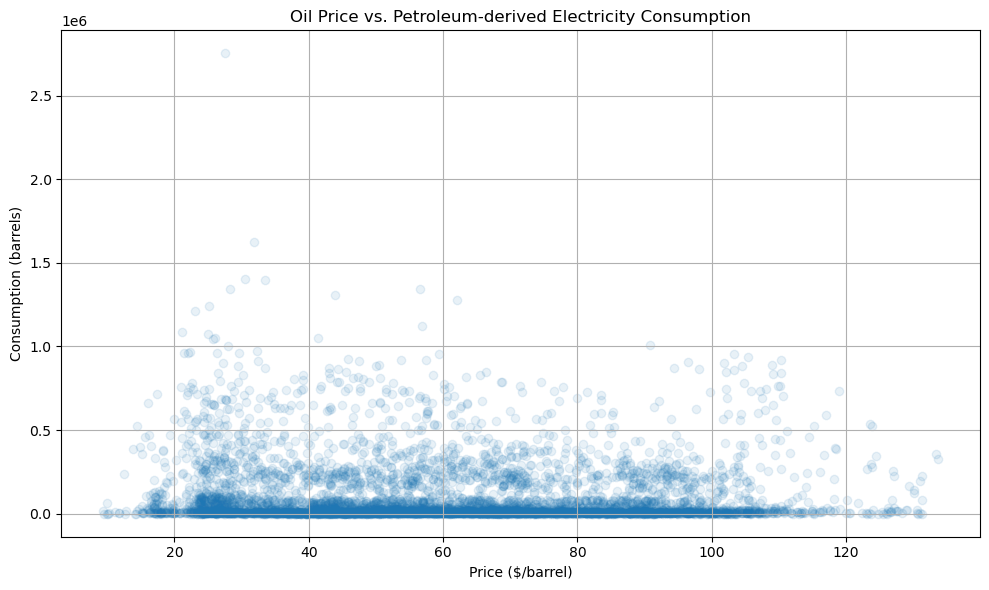

In [ ]:
# visualize treatment vs outcome
plt.figure(figsize=(10, 6))
plt.scatter(df['Price'], df['CONSUMPTION'], alpha=0.1)
plt.xlabel('Price ($/barrel)')
plt.ylabel('Consumption (barrels)')
plt.title('Oil Price vs. Petroleum-derived Electricity Consumption')
plt.grid(True)
plt.tight_layout()
plt.show()

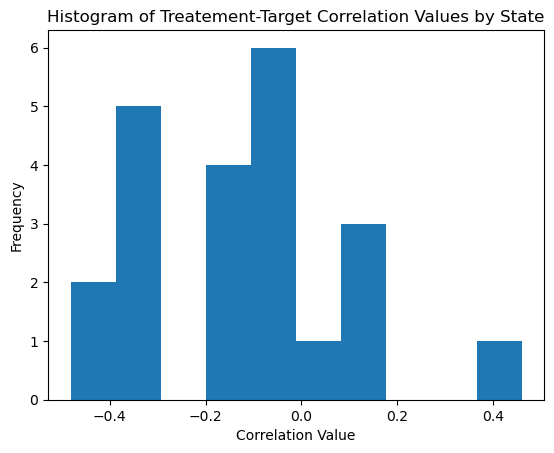

In [ ]:
# visualize treatment - outcome correlations state by state
state_vals = df['state'].unique()
corr_vals = []
for curr_val in state_vals:
  curr_df = df[df['state'] == curr_val]
  corr_vals.append(curr_df['Price'].corr(curr_df['CONSUMPTION']))

plt.hist(corr_vals, bins=10)
plt.xlabel('Correlation Value')
plt.ylabel('Frequency')
plt.title('Histogram of Treatement-Target Correlation Values by State')
plt.show()

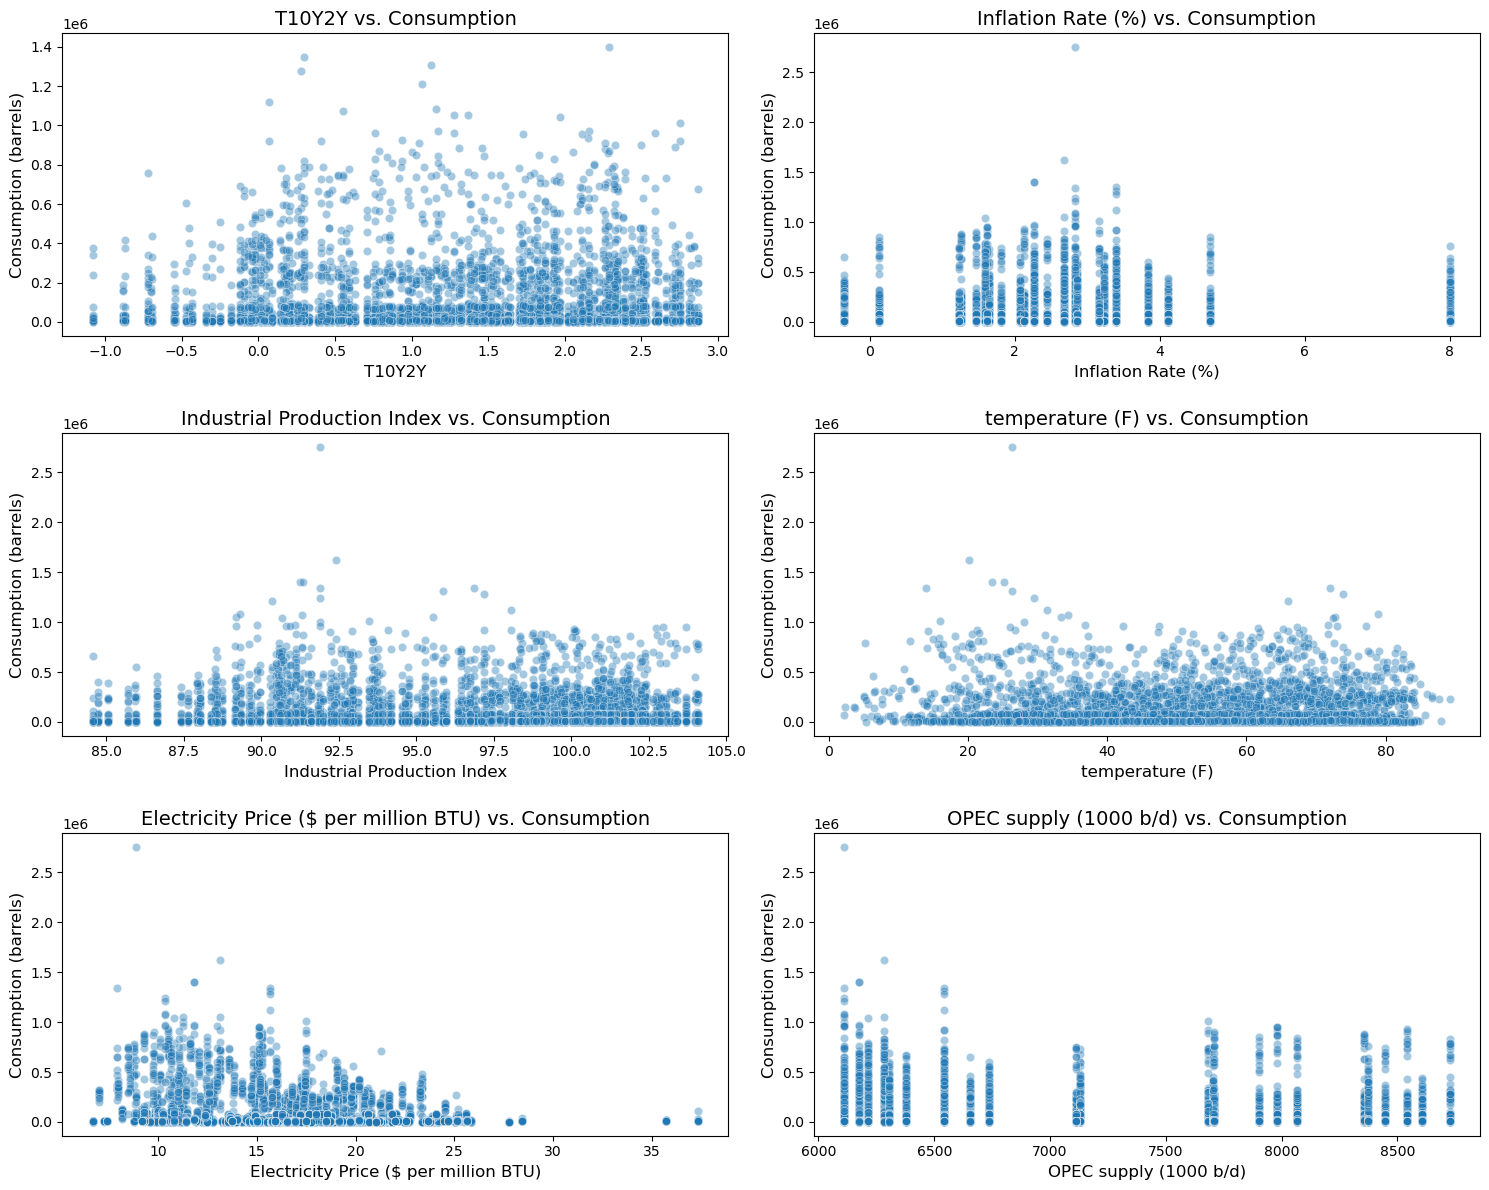

In [ ]:
# visualize confounder - outcome relationships
target = 'CONSUMPTION'
exclude_features = ['Period', 'Year', 'Month', 'CONSUMPTION', 'state', 'State_Code']
features = [col for col in df.columns if col not in exclude_features]
features = features[-6:]

nrows, ncols = 3, 2
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 12))
axes = axes.flatten()

num_plots = len(features)

for i in range(num_plots):
    feature = features[i]
    ax = axes[i]

    sns.scatterplot(x=df[feature], y=df[target], alpha=0.4, ax=ax)

    ax.set_title(f'{feature} vs. Consumption', fontsize=14)
    ax.set_xlabel(feature, fontsize=12)
    ax.set_ylabel('Consumption (barrels)', fontsize=12)

for j in range(num_plots, nrows * ncols):
    if j < len(axes):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Modeling

### Feature Engineering

In [ ]:
# one hot encode state column
df = pd.get_dummies(df, columns=['state'], dtype=int)
df.head()

,State_Code,Period,Price,Year,Month,TYPE OF PRODUCER,ENERGY SOURCE (UNITS),CONSUMPTION,T10Y2Y,Inflation Rate (%),...,state_ND,state_NE,state_NM,state_OH,state_OK,state_PA,state_SD,state_TX,state_UT,state_WV
0,F001242__3,2001-01-01,28.02,2001,1,Total Electric Power Industry,Petroleum (Barrels),1005652,NaN,2.826171,...,0,0,0,0,0,1,0,0,0,0
1,F001242__3,2001-02-01,28.52,2001,2,Total Electric Power Industry,Petroleum (Barrels),196117,0.55,2.826171,...,0,0,0,0,0,1,0,0,0,0
2,F001242__3,2001-03-01,26.20,2001,3,Total Electric Power Industry,Petroleum (Barrels),478840,0.46,2.826171,...,0,0,0,0,0,1,0,0,0,0
3,F001242__3,2001-04-01,26.31,2001,4,Total Electric Power Industry,Petroleum (Barrels),960097,0.76,2.826171,...,0,0,0,0,0,1,0,0,0,0
4,F001242__3,2001-05-01,27.43,2001,5,Total Electric Power Industry,Petroleum (Barrels),524322,1.07,2.826171,...,0,0,0,0,0,1,0,0,0,0


In [ ]:
for col in df.columns:
  print(f"column: {col}, type: {type(df[col].iloc[0])}")

column: State_Code, type: <class 'str'>
column: Period, type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>
column: Price, type: <class 'numpy.float64'>
column: Year, type: <class 'numpy.int32'>
column: Month, type: <class 'numpy.int32'>
column: TYPE OF PRODUCER, type: <class 'str'>
column: ENERGY SOURCE              (UNITS), type: <class 'str'>
column: CONSUMPTION, type: <class 'numpy.int64'>
column: T10Y2Y, type: <class 'numpy.float64'>
column: Inflation Rate (%), type: <class 'numpy.float64'>
column: Industrial Production Index, type: <class 'numpy.float64'>
column: temperature (F), type: <class 'numpy.float64'>
column: Electricity Price ($ per million BTU), type: <class 'numpy.float64'>
column: OPEC supply (1000 b/d), type: <class 'numpy.int64'>
column: state_AL, type: <class 'numpy.int64'>
column: state_AR, type: <class 'numpy.int64'>
column: state_CA, type: <class 'numpy.int64'>
column: state_CO, type: <class 'numpy.int64'>
column: state_IL, type: <class 'numpy.int64'>
colum

In [ ]:
# apply seasonality feature
model_df = df.copy()
model_df['time_idx'] = (model_df['Year'] - 2000) * 12 + (model_df['Month'] - 1)
model_df['month_sin'] = np.sin(2 * np.pi * model_df['Month'] / 12)
model_df['month_cos'] = np.cos(2 * np.pi * model_df['Month'] / 12)
model_df.rename(columns={'ENERGY SOURCE              (UNITS)': 'ENERGY SOURCE (UNITS)'}, inplace=True)

# Set to ordered format
model_df['Period'] = pd.to_datetime(model_df['Period'])

model_df.drop(columns=['State_Code', 'TYPE OF PRODUCER', 'ENERGY SOURCE (UNITS)'], inplace=True)
print(model_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5947 entries, 0 to 5946
Data columns (total 36 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Period                                 5947 non-null   datetime64[ns]
 1   Price                                  5947 non-null   float64       
 2   Year                                   5947 non-null   int32         
 3   Month                                  5947 non-null   int32         
 4   CONSUMPTION                            5947 non-null   Int64         
 5   T10Y2Y                                 5302 non-null   float64       
 6   Inflation Rate (%)                     5947 non-null   float64       
 7   Industrial Production Index            5947 non-null   float64       
 8   temperature (F)                        5947 non-null   float64       
 9   Electricity Price ($ per million BTU)  5947 non-null   float64 

### Estimate ATE using Horvitz–Thompson formula

In [ ]:
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

In [ ]:
# remove NaN values from dataset
model_df = model_df.dropna(inplace=True)

In [ ]:
random_state=42
treatment = 'Price'
outcome = 'CONSUMPTION'

ate_df = model_df.copy()

treatment_med = ate_df['Price'].median()
T = np.where(ate_df['Price'] >= treatment_med, 1, 0).astype(np.int32)
ate_df.drop(columns=['Period', 'Year', 'Month'], errors='ignore', inplace=True)
features = [col for col in ate_df.columns if col not in ['CONSUMPTION', 'Price']]
X_confounders = ate_df[features]
X_array = X_confounders.values.astype(float)
X_confounders_sm = sm.add_constant(X_array, prepend=True)
T_array = T.astype(float)

# Run the Logit model
logit_model = sm.Logit(T_array, X_confounders_sm)
logit_results = logit_model.fit(disp=0)

# Calculate propensity scores
propensity_scores = logit_results.predict(X_confounders_sm)
ate_df['propensity_score'] = propensity_scores
ate_df['T'] = T

# Perform Trimming on Extreme Propensity Values
lower, upper = 0.025, 0.975
mask = (
    (ate_df['propensity_score'] > lower) &
    (ate_df['propensity_score'] < upper)
)
ate_trim = ate_df.loc[mask].copy()

Y = ate_trim[outcome].values
T_trim = ate_trim['T'].values
e = ate_trim['propensity_score'].values
N = len(ate_trim)

# Horvitz–Thompson IPW ATE formula: Sum[ (T*Y/e) - ((1-T)*Y/(1-e)) ] / N
ate_ht = (1 / N) * np.sum(
    (T_trim * Y / e) - ((1 - T_trim) * Y / (1 - e))
)
print(f"Horvitz–Thompson IPW ATE (HT): {ate_ht:.4f}")

Horvitz–Thompson IPW ATE (HT): -6915.6903


According to our findings, a $1 increase in price causes, on average, a decrease of about 6,916 barrels of oil consumption.